<a href="https://colab.research.google.com/github/sushanthnprabhu-netizen/Assignments/blob/main/assignment_2_n2n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [ ]:
#code here
class NANDPerceptron:
    def __init__(self):
        self.weights = np.array([-1, -1])
        self.bias = 1.5

    def predict(self, X):
        z = X @ self.weights + self.bias
        return (z > 0).astype(int)


nand = NANDPerceptron()

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

print(nand.predict(X))

[1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:** A perceptron changes its output based on a fixed threshold. If the value is slightly above the threshold, the output is 1, and if it is slightly below, the output becomes 0. Because of this, even a very small change in a weight can sometimes change the output completely. In a network, this change can affect other perceptrons as well, causing a big difference in the final result.


### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:** As the value of c approaches infinity, the sigmoid neuron starts behaving like a perceptron. This happens because the sigmoid curve becomes steeper and steeper, and in the limit it acts like a step function that suddenly switches between 0 and 1.

We prefer sigmoid neurons because they change smoothly instead of abruptly. This smooth behavior makes it possible to calculate gradients and train neural networks using gradient descent, which is not possible with a perceptron's hard threshold.


---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:** The factor of 1/2 is added to make differentiation easier. When we take the derivative of the squared term, a factor of 2 appears. The 1/2 in front cancels this 2, making the final derivative simpler to write and compute.

Without the 1/2, the derivative would contain an extra factor of 2 everywhere. The value of the cost function does not change in any important way, but the mathematics becomes cleaner.


### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:** For the first example, the squared error is (0.9 − 1.0)² = 0.01. For the second example, the squared error is (0.3 − 0.0)² = 0.09. Adding them gives a total error of 0.10.

Since there are 2 training examples,

C = (1 / (2 × 2)) × 0.10 = 0.025

So the cost is 0.025. This is a small value, which means the network's predictions are fairly close to the target values. A lower cost indicates better network performance, while a higher cost means the predictions are farther from the correct answers.


In [ ]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

C_val = None  # TODO: compute C
n = len(outputs)

C_val = (1 / (2 * n)) * np.sum((outputs - targets) ** 2)

print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:** We use a cost function because it tells us how wrong the network's predictions are and gives a smooth value that can be improved gradually. Classification accuracy only tells us whether a prediction is correct or incorrect, so it does not show how close a wrong prediction was to the correct answer.

Cost functions provide useful gradients that help the network adjust its weights during training. Because of this, neural networks can learn efficiently using gradient descent.


### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:** One problem with absolute error is that it is not smooth at the point where the error is zero. At that point, the derivative is undefined, which can make gradient descent difficult to apply. Squared error is smoother and has well-defined derivatives everywhere, making it easier for the network to learn and update its weights.


---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:** The cost function is always non-negative because both terms are squared. A squared value becomes zero only when the quantity inside the bracket is zero.

The first term, (w − 3)², is minimized when w = 3. The second term, 2(b − 1)², is minimized when b = 1. Therefore, the minimum cost occurs at w = 3 and b = 1.

Substituting these values gives:

C = (3 − 3)² + 2(1 − 1)² = 0

So the minimum value of C is 0.


### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:** Given:

C(w,b) = (w − 3)² + 2(b − 1)²

The derivatives are:

dC/dw = 2(w − 3)

dC/db = 4(b − 1)

Starting at (w,b) = (0,0) with learning rate η = 0.1:

Step 1:

dC/dw = 2(0 − 3) = −6

dC/db = 4(0 − 1) = −4

w = 0 − 0.1(−6) = 0.6

b = 0 − 0.1(−4) = 0.4

After Step 1: (w,b) = (0.6, 0.4)

Step 2:

dC/dw = 2(0.6 − 3) = −4.8

dC/db = 4(0.4 − 1) = −2.4

w = 0.6 − 0.1(−4.8) = 1.08

b = 0.4 − 0.1(−2.4) = 0.64

After Step 2: (w,b) = (1.08, 0.64)

So after two gradient descent steps, the parameter vector moves from (0,0) to (1.08, 0.64), which is closer to the minimum point (3,1).


In [ ]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2 * (w - 3) # TODO
    db = 4 * (b - 1) # TODO
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:** If we start with b = 0 and use η = 0.6:

dC/db = 4(b − 1) = 4(0 − 1) = −4

b_new = 0 − 0.6(−4) = 2.4

The optimal value of b is 1, but the update jumps all the way to 2.4 and overshoots the minimum. On the next update, the gradient changes direction and b jumps back the other way. This can cause oscillations and make training unstable.

This shows that choosing a learning rate is important. If the learning rate is too large, gradient descent can overshoot the minimum and may not converge properly.


In [ ]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
      # TODO: compute z = w.x + b, return sigmoid(z)
      z = np.dot(self.weights, x) + self.bias
      return 1 / (1 + np.exp(-z))


    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        # return (grad_weights, grad_bias)
        grad_weights = np.zeros_like(self.weights)
        for i in range(len(self.weights)):
            w_old = self.weights[i]

            self.weights[i] = w_old + h
            f_plus = self.forward(x)

            self.weights[i] = w_old - h
            f_minus = self.forward(x)

            grad_weights[i] = (f_plus - f_minus) / (2 * h)

            self.weights[i] = w_old

        b_old = self.bias

        self.bias = b_old + h
        f_plus = self.forward(x)

        self.bias = b_old - h
        f_minus = self.forward(x)

        grad_bias = (f_plus - f_minus) / (2 * h)

        self.bias = b_old

        return grad_weights, grad_bias


### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [ ]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:** The gradient with respect to w1 tells us how much the neuron's output changes when w1 is changed slightly. Since the gradient is positive, increasing w1 will increase the output of the neuron. The size of the gradient shows how sensitive the output is to changes in w1. A larger gradient means a small change in w1 has a bigger effect on the output.


### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**

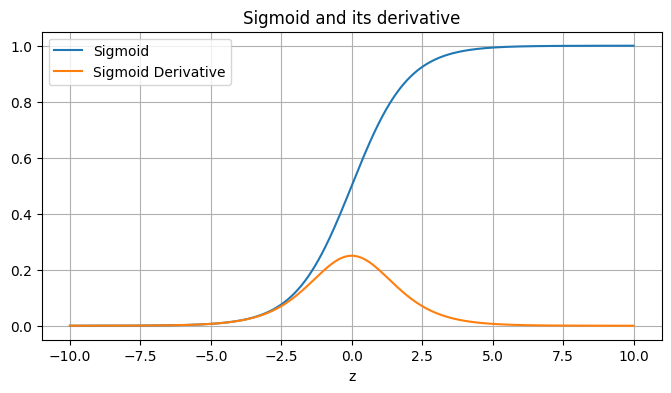

In [ ]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma = 1 / (1 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.plot(z, sigma, label='Sigmoid')
plt.plot(z, sigma_prime, label='Sigmoid Derivative')
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:** The claim is mostly correct. When the weights and bias are multiplied by a very large number such as 100, the sigmoid curve becomes extremely steep and starts looking like a step function. Because of this, the sigmoid neuron behaves almost like a perceptron.

However, it is not exactly the same. Near the threshold, the sigmoid still produces smooth values between 0 and 1, while a perceptron jumps instantly from 0 to 1. The similarity breaks down when we need gradients for learning, because the sigmoid remains differentiable whereas the perceptron does not.


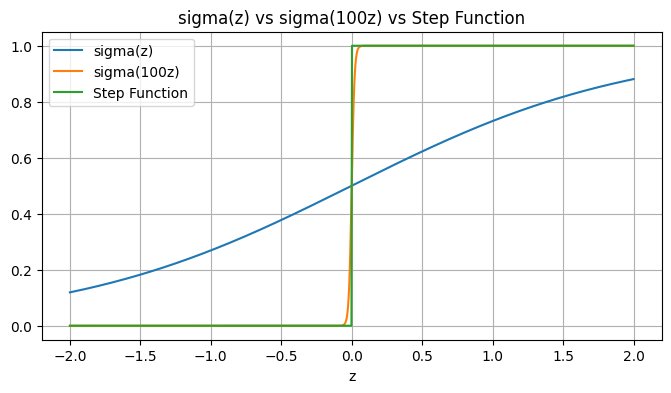

In [ ]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function
sigma = 1 / (1 + np.exp(-z))
sigma_100 = 1 / (1 + np.exp(-100 * z))
step = (z >= 0).astype(int)

plt.figure(figsize=(8, 4))
# TODO: plot all three
plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_100, label='sigma(100z)')
plt.plot(z, step, label='Step Function')
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:** For a prediction:

ŷ = wx + b

Using the quadratic cost function:

C = (1/2n) Σ(ŷ − y)²

Substituting ŷ = wx + b:

C = (1/2n) Σ(wx + b − y)²

Differentiating with respect to w:

dC/dw = (1/n) Σ(wx + b − y)x

Differentiating with respect to b:

dC/db = (1/n) Σ(wx + b − y)

These gradients are used in gradient descent updates:

w = w − η(dC/dw)

b = b − η(dC/db)


Final w = 2.9910, b = 1.0256


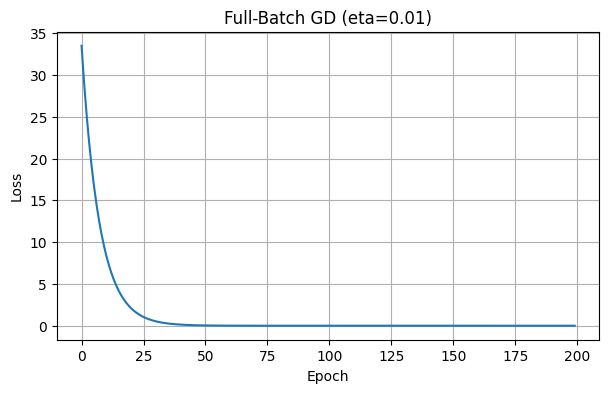

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses = []

for epoch in range(200):
    # TODO: predictions, loss, gradients, update
    y_pred = w * X_train + b
    loss = np.mean((y_pred - y_train) ** 2) / 2
    dw = np.mean((y_pred - y_train) * X_train)
    db = np.mean(y_pred - y_train)

    w = w - eta * dw
    b = b - eta * db

    losses.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:** The SGD loss curve is usually noisier than the full-batch loss curve. This is because SGD updates the weights using only one training example at a time, so the gradient estimate is less accurate and varies from step to step.

Full-batch gradient descent uses all training examples to compute the gradient, so the updates are smoother and more stable. SGD is noisier, but it can sometimes learn faster because it updates the parameters more frequently.


Final w = 2.9621, b = 1.1061


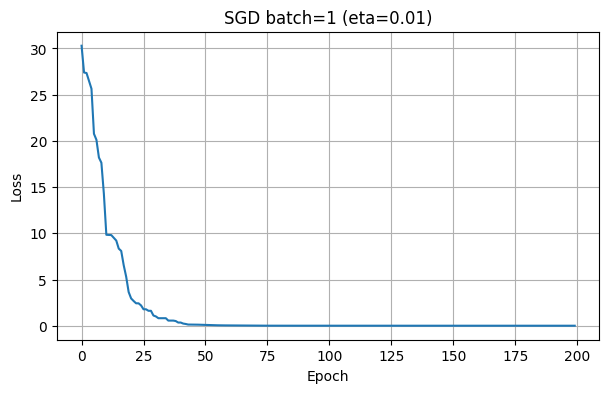

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):
    # TODO: pick random example, compute gradient, update
    idx = np.random.randint(len(X_train))
    x = X_train[idx]
    y = y_train[idx]

    y_pred = w * x + b

    dw = (y_pred - y) * x
    db = (y_pred - y)

    w -= eta * dw
    b -= eta * db
    loss =  np.mean((w * X_train + b - y_train) ** 2) / 2
    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:** With a learning rate of 0.5, the updates become too large and the parameters overshoot the minimum. Instead of moving closer to the optimal values, the weights keep jumping from one side of the minimum to the other, causing the loss to increase.

From Q5a, the gradients are:

dC/dw = (1/n) Σ(wx + b − y)x

dC/db = (1/n) Σ(wx + b − y)

When the error term (wx + b − y) becomes large, the gradients also become large. Multiplying these large gradients by η = 0.5 produces very large updates, which causes the training process to become unstable and diverge.


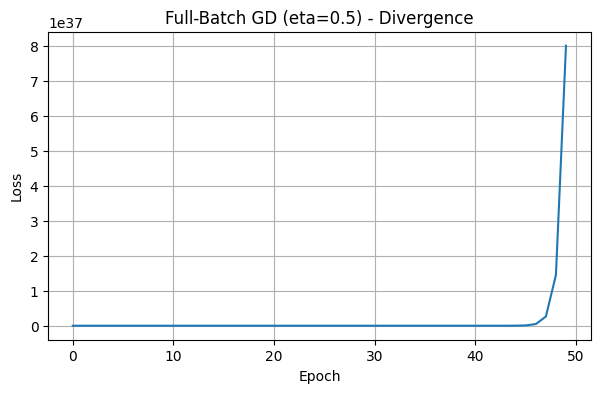

In [ ]:
w, b = 0.0, 0.0
losses_div = []

for epoch in range(50):

    eta = 0.5

    y_pred = w * X_train + b

    loss = np.mean((y_pred - y_train) ** 2) / 2

    dw = np.mean((y_pred - y_train) * X_train)
    db = np.mean(y_pred - y_train)

    w -= eta * dw
    b -= eta * db

    losses_div.append(loss)

    if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:** A 4-bit binary number can represent values from 0 to 15, so it is enough to represent the digits 0 to 9. The final layer therefore needs 4 output neurons, where each neuron represents one bit of the binary code.

The outputs would be:

0 → 0000

1 → 0001

2 → 0010

3 → 0011

4 → 0100

5 → 0101

6 → 0110

7 → 0111

8 → 1000

9 → 1001

The input to this layer is a 10-neuron one-hot vector. Since only one input neuron is active for each digit, the weight matrix can be constructed by placing the binary representation of each digit in the corresponding row.

Weight matrix:

[[0,0,0,0],
[0,0,0,1],
[0,0,1,0],
[0,0,1,1],
[0,1,0,0],
[0,1,0,1],
[0,1,1,0],
[0,1,1,1],
[1,0,0,0],
[1,0,0,1]]

Bias vector:

[0, 0, 0, 0]

When a one-hot digit vector is multiplied by this matrix, the output becomes the correct 4-bit binary encoding of that digit.


In [ ]:
# TODO: define W (4x10) and b_enc (4,)
W = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
], dtype=float)

b_enc = np.zeros(4)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:** Gradient descent can be viewed as moving along a curve to find its lowest point. The derivative dC/dv gives the slope of the curve at the current position. If the slope is positive, the update moves v to the left, and if the slope is negative, the update moves v to the right.

The learning rate α controls the size of each step. A small α makes slow and careful progress, while a large α takes bigger steps and may overshoot the minimum. Together, the slope determines the direction of movement and the learning rate determines how far we move along the curve.


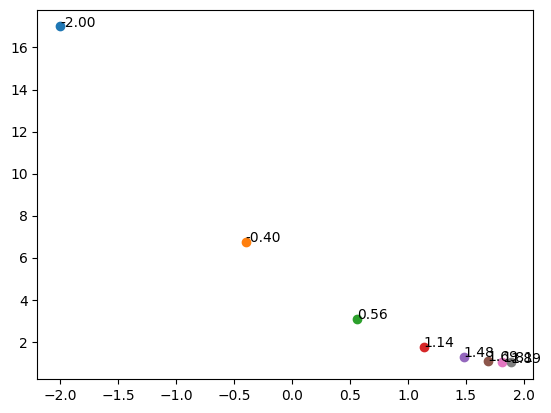

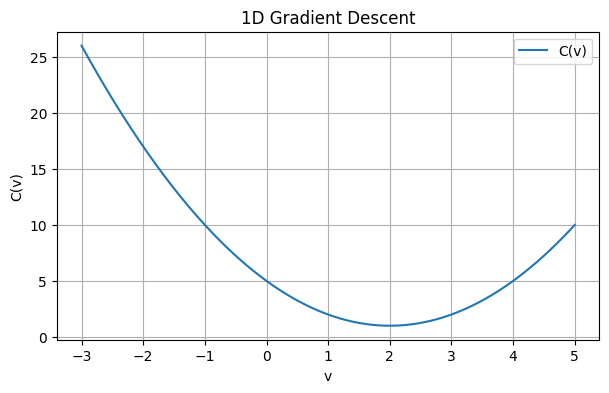

In [ ]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

# TODO: run gradient descent steps and annotate on the curve
v = -2.0
alpha = 0.2

for _ in range(8):
    C = (v - 2)**2 + 1

    plt.scatter(v, C)
    plt.annotate(f'{v:.2f}', (v, C))

    grad = 2 * (v - 2)
    v = v - alpha * grad
plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')
plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:** If we remove all hidden layers and connect the 784 input pixels directly to the 10 output neurons, the network becomes a simple linear classifier. It is similar to logistic regression or a single-layer neural network.

The classification accuracy is limited because the model can only learn linear relationships. Many real-world patterns, such as handwritten digits, are not perfectly linearly separable, so the model cannot capture complex features and shapes.

This shows why hidden layers are important. Hidden layers allow the network to learn non-linear patterns and more complex features, which greatly improves classification performance.
